In [1]:
%load_ext autoreload
%autoreload 2

In [45]:
import os
import copy
import platform
import subprocess
import json
from io import StringIO
import numpy as np
import pandas as pd
import networkx as nx
from networkx.readwrite import json_graph
from pathlib import Path
from collections import defaultdict


from html_from_assignments import NMRProblem
import jsonUtils

import nmrsolution
# from globals import svgDimensions

from globals import SVG_DIMENSIONS as svgDimensions
from simulatedAnnealing_v5 import SimulatedAnnealing2

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

In [46]:
%matplotlib inline

In [47]:
if platform.system() == "Darwin":

    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043/04164043_assignments.json")
    fn_json = Path("/opt/topspin4.5.0/examdata/exam_CMCse_1/exam_CMCse_1_assignments.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B3/Cytochalasin-B_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B-kate/Cytochalasin-B-kate_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/menthol/menthol_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/CSM_xnjl48_24132826_E72603/CSM_xnjl48_24132826_E72603_assignments_mresnova.json")


elif platform.system() == "Windows":
    fn_json = Path(r"C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\bruker_data_sets\E72507_04164043_propyl_benzoate\04164043\04164043_jeol_inputdata.json")
    

In [48]:
fn_json, "\n", fn_json.exists()

(PosixPath('/Users/vsmw51/Dropbox/4Eric/CSM_xnjl48_24132826_E72603/CSM_xnjl48_24132826_E72603_assignments_mresnova.json'),
 '\n',
 True)

In [49]:
with open(fn_json, 'r') as f:
    json_data = json.load(f)

In [50]:
problemdata_json = NMRProblem.from_mnova_dict(json_data)


from_mnova_dict(cls,json_data: dict):

Processing key: smiles
	data[smiles].keys()
 dict_keys(['datatype', 'count', 'data']) 

v.items():
 dict_items([('datatype', 'smiles'), ('count', 1), ('data', {'0': 'CCC1(COC(C=C)=O)COCOC1'})]) 

Processing key: molfile
	data[molfile].keys()
 dict_keys(['datatype', 'count', 'data']) 

v.items():
 dict_items([('datatype', 'molfile'), ('count', 1), ('data', {'0': '\r\n  E 2024-003252611032D\r\n\r\n 14 14  0  0  0  0  0  0  0  0999 V2000\r\n    8.4482    1.0296    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    8.4482    2.4296    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\r\n    7.2358    3.1296    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    6.0233    2.4296    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    6.0233    1.0296    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    7.2358    0.3296    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\r\n    4.8109    3.1296    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    3.5

In [51]:
solution = nmrsolution.NMRsolution(problemdata_json)

self.expts_available {'HMBC', 'HSQC', 'COSY', 'SKIP'}
problemdata_json.dataframes.keys() dict_keys(['smiles', 'molfile', 'allAtomsInfo', 'carbonAtomsInfo', 'nmrAssignments', 'c13predictions', 'chosenSpectra', 'MNOVAcalcMethod', 'workingDirectory', 'workingFilename', 'simulatedAnnealing', 'spectraWithPeaks', 'molecule', 'HSQC', 'HMBC', 'COSY', 'H1_1D', 'C13_1D', 'DEPT135', 'H1_pureshift', 'HSQC_CLIPCOSY', 'DDEPTCH3ONLY', 'NOESY'])
Prediction from NMRSHIFTDB2
Prediction from NMRSHIFTDB2
BEFORE ::: self.molprops_df
    idx  atom_idx  implicitHs  totalNumHs  degree  hybridization  aromatic
0    0         0           2           2       2              4     False
1    2         2           2           2       2              4     False
2    3         3           0           0       4              4     False
3    4         4           2           2       2              4     False
4    6         6           2           2       2              4     False
5    8         8           2         

In [52]:
dir(solution)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'add_CH0_CH1_CH2_CH3_CH3CH1_to_C13',
 'add_CH0_CH1_CH2_CH3_CH3CH1_to_C13_df',
 'add_CH2_CH3CH_to_hsqc_dataframes',
 'assign_CH3_CH1_in_HSQC_using_H1',
 'assign_CH3_CH1_in_HSQC_using_expected_molecule',
 'assign_CH3_CH2_CH1_in_HSQC_using_Assignments',
 'assign_CH3_CH2_CH1_in_HSQC_using_DoubleDept',
 'assign_CH3_CH2_CH1_overall',
 'attempt_assignment_CH3_CH2_CH1_to_C13_table',
 'c13_df',
 'c13predictions',
 'carbonAtomsInfo',
 'check_c13_not_empty',
 'check_h1_pureshift_not_empty',
 'check_hsqc_assign_CH2_from_DEPT135',
 'check_hsqc_df_not_empty',
 'check_what_e

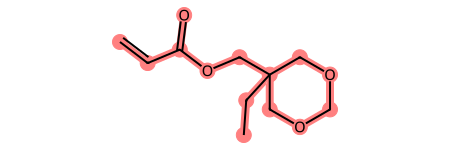

In [53]:
solution.expected_molecule

In [54]:
solution.expected_molecule.molprops_df.columns

Index(['atom_idx', 'implicitHs', 'totalNumHs', 'degree', 'hybridization',
       'aromatic', 'numProtons', 'idx', 'quaternary', 'CH0', 'CH1', 'CH2',
       'CH3', 'CH3CH1', 'picked', 'ppm', 'atomNumber', 'ring_idx', 'ring_size',
       'ring_idx0', 'ring_size0', 'x', 'y', 'symmetry_idx1', 'symmetry_idx2',
       'sym_atom_idx', 'sym_atomNumber'],
      dtype='object')

In [55]:
solution.expected_molecule.molprops_df[["ppm", "atom_idx", "atomNumber",  "sym_atom_idx", "sym_atomNumber"]]


,ppm,atom_idx,atomNumber,sym_atom_idx,sym_atomNumber
idx,,,,,
0,93.60,0,1,,
2,72.44,2,3,4,5
3,41.96,3,4,,
4,72.44,4,5,2,3
6,72.44,6,7,,
8,23.49,8,9,,
9,7.90,9,10,,
10,165.85,10,11,,
11,128.19,11,12,,


In [44]:
def get_symmetry_classes(mol):
    # mol = Chem.AddHs(mol)
    # Generate canonical ranks (same rank = same symmetry class)
    ranks = list(Chem.CanonicalRankAtoms(mol, breakTies=False))

    print(ranks)
    
    classes = defaultdict(list)
    for idx, rank in enumerate(ranks):
        classes[rank].append(idx)
        
    return classes

mol = solution.expected_molecule.mol
molprops_df = solution.expected_molecule.molprops_df

# set the columns sym_atom_idx and sym_atomNumber to ""
molprops_df["sym_atom_idx"] = ""
molprops_df["sym_atomNumber"] = ""

# mol = Chem.MolFromSmiles('CC(C)O') # Isopropanol
sym_classes = get_symmetry_classes(solution.expected_molecule.mol)
for rank, atoms in sym_classes.items():
    # find the atom symbol in the atoms and create a list
    if len(atoms) == 1:
        continue
    # skip if atom is not carbon
    atom_symbols = [solution.expected_molecule.mol.GetAtomWithIdx(idx).GetSymbol() for idx in atoms]
    if not all(symbol == "C" for symbol in atom_symbols):
        continue
    print(f"Symmetry Class {rank}: Atom Indices {atoms}, Atom Symbols {atom_symbols}")

    atomNumbers = molprops_df[molprops_df['atom_idx'].isin(atoms)]["atomNumber"].tolist()
    for i, idx in enumerate(atoms):
        # creat a new list with the value at index i in th atoms removed
        other_atoms = atoms[:i] + atoms[i+1:]
        other_atomNumbers = atomNumbers[:i] + atomNumbers[i+1:]
        # create a comma separated string of the other atoms
        other_atoms_str = ", ".join(str(a) for a in other_atoms)
        other_atomNumbers_str = ", ".join(str(a) for a in other_atomNumbers)
        print(f"  Atom {idx} is symmetric to atoms {other_atoms_str}")
        molprops_df.at[idx, "sym_atom_idx"] = other_atoms_str
        molprops_df.at[idx, "sym_atomNumber"] = other_atomNumbers_str

molprops_df[["ppm", "atom_idx", "atomNumber",  "sym_atom_idx", "sym_atomNumber"]]

[4, 9, 6, 13, 6, 9, 8, 11, 5, 1, 12, 3, 0, 2]
Symmetry Class 6: Atom Indices [2, 4], Atom Symbols ['C', 'C']
  Atom 2 is symmetric to atoms 4
  Atom 4 is symmetric to atoms 2


,ppm,atom_idx,atomNumber,sym_atom_idx,sym_atomNumber
idx,,,,,
0,93.60,0,1,,
2,72.44,2,3,4,5
3,41.96,3,4,,
4,72.44,4,5,2,3
6,72.44,6,7,,
8,23.49,8,9,,
9,7.90,9,10,,
10,165.85,10,11,,
11,128.19,11,12,,


In [43]:
# find rows in molpropsd_df where atom_idx the list [2, 3, 5] and return the "atomNumber" column values
rows = molprops_df[molprops_df['atom_idx'].isin([2, 3, 6])]["atomNumber"].tolist()
rows

['3', '4', '7']

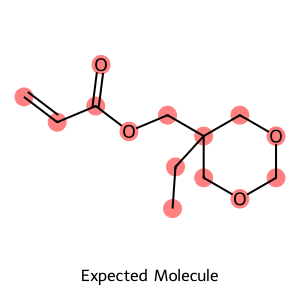

In [33]:
mol = solution.expected_molecule.mol

# display the molecule with atom indices
Draw.MolToImage(mol, size=(300, 300), kekulize=True, legend="Expected Molecule", highlightAtoms=range(mol.GetNumAtoms()))